In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("student_habits_performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df.shape

(1000, 16)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set(style = "whitegrid")

In [8]:
int(df.isna().sum().sum())

91

In [9]:
df = df.dropna()

In [10]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [14]:
#For Categorical columns Summary
df.describe(include = "object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [15]:
categorical_cols = ["gender", "part_time_job", "diet_quality", "parental_education_level","internet_quality","extracurricular_participation"]

In [16]:
for col in categorical_cols:
    print(f"Value counts for {col}:\n {df[col].value_counts()}")

Value counts for gender:
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job:
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality:
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level:
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality:
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation:
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


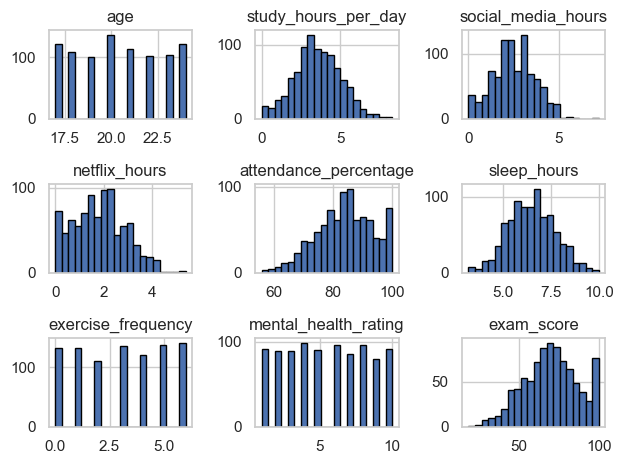

In [17]:
df.hist(bins = 20, edgecolor = "black")
plt.tight_layout()
plt.show()

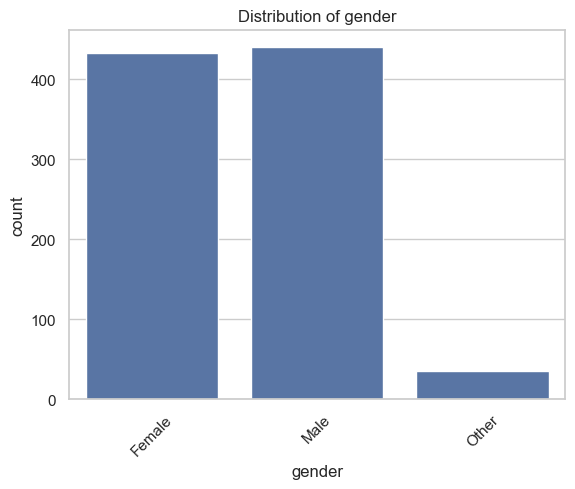

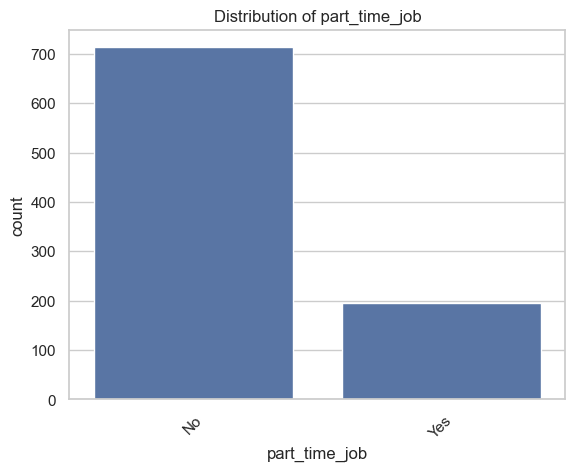

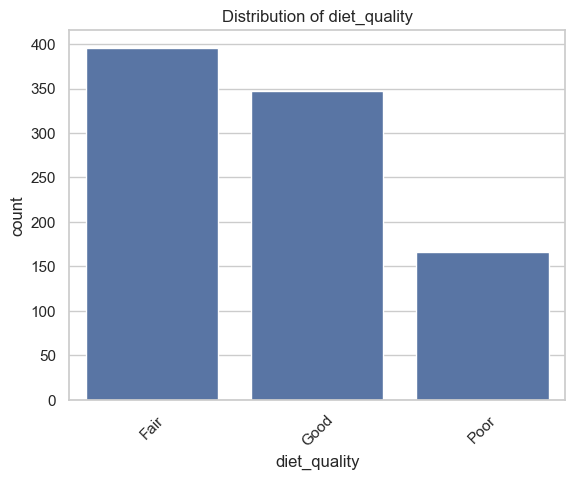

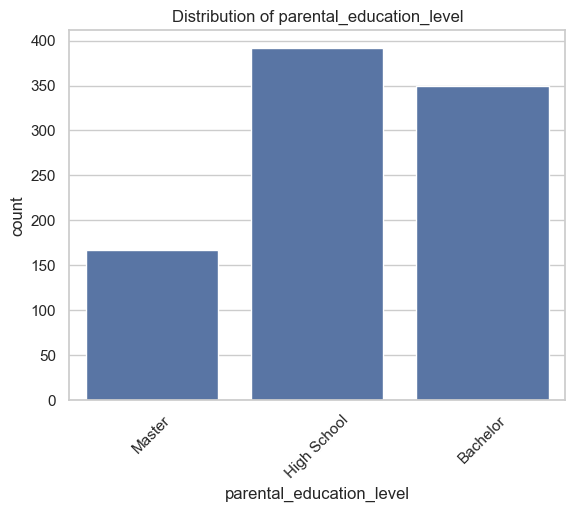

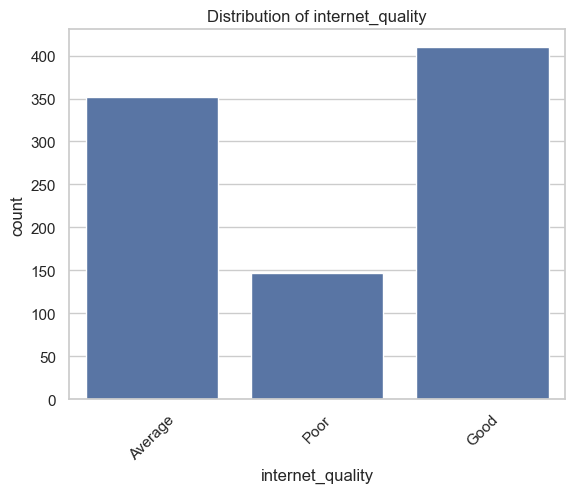

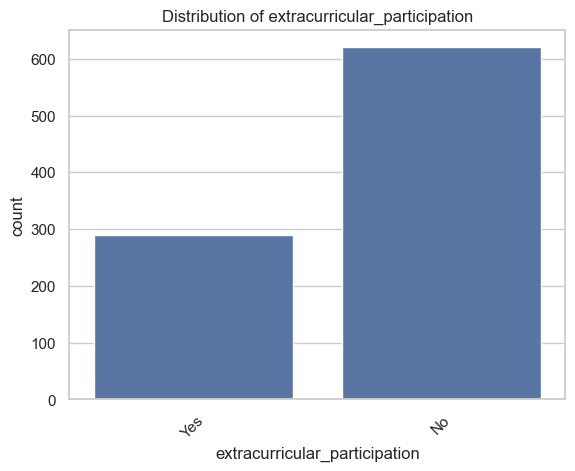

In [18]:
for col in categorical_cols:
    sns.countplot(data = df, x = col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()

In [19]:
corr = df.corr(numeric_only = True)
corr

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.007150,-0.023854,0.005841,-0.030203,0.040498,-0.005718,-0.052137,-0.012833
study_hours_per_day,0.007150,1.000000,0.007364,-0.014493,0.028967,-0.026241,-0.024708,-0.015896,0.822950
social_media_hours,-0.023854,0.007364,1.000000,0.011865,0.049356,0.026861,-0.023975,-0.000417,-0.171672
netflix_hours,0.005841,-0.014493,0.011865,1.000000,-0.015008,-0.017006,-0.004155,-0.016612,-0.166578
attendance_percentage,-0.030203,0.028967,0.049356,-0.015008,1.000000,0.001972,-0.010563,-0.017096,0.096005
sleep_hours,0.040498,-0.026241,0.026861,-0.017006,0.001972,1.000000,0.030013,-0.010653,0.122294
exercise_frequency,-0.005718,-0.024708,-0.023975,-0.004155,-0.010563,0.030013,1.000000,-0.001500,0.161397
mental_health_rating,-0.052137,-0.015896,-0.000417,-0.016612,-0.017096,-0.010653,-0.001500,1.000000,0.317945
exam_score,-0.012833,0.822950,-0.171672,-0.166578,0.096005,0.122294,0.161397,0.317945,1.000000


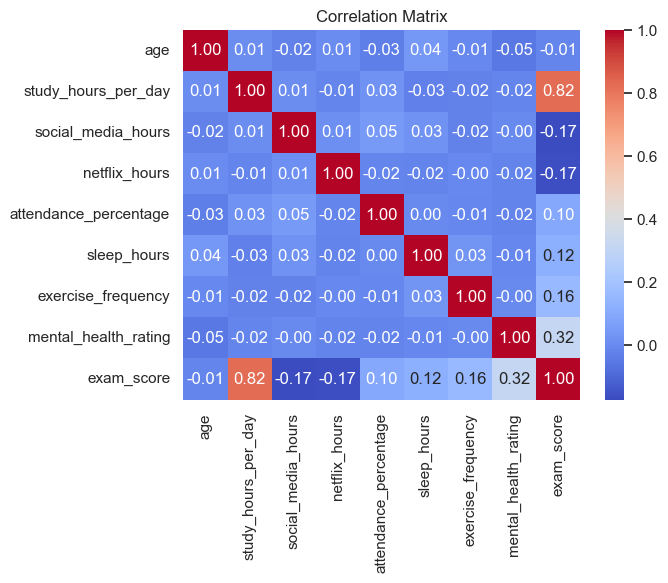

In [20]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

In [21]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [22]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

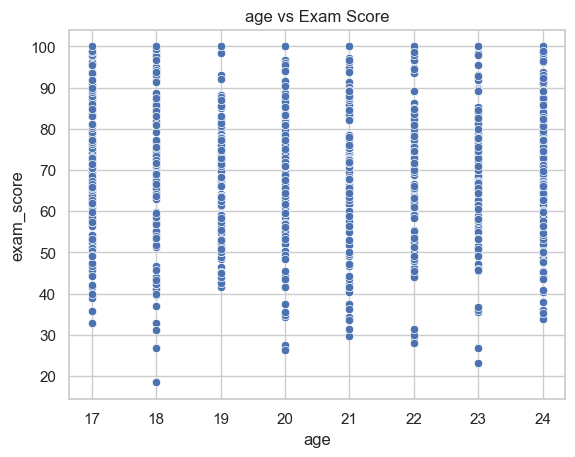

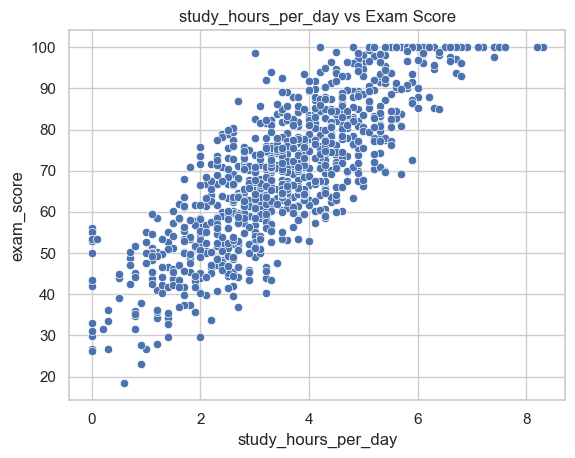

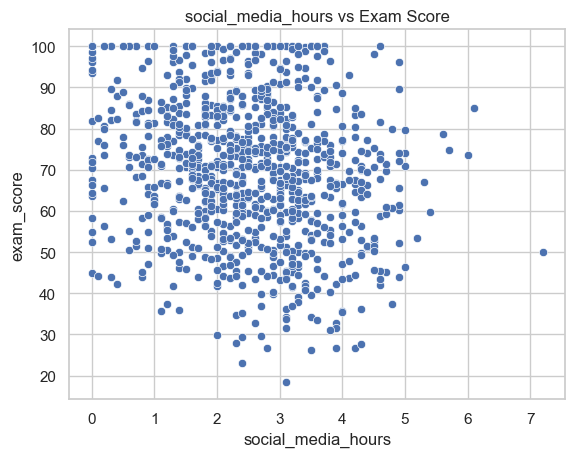

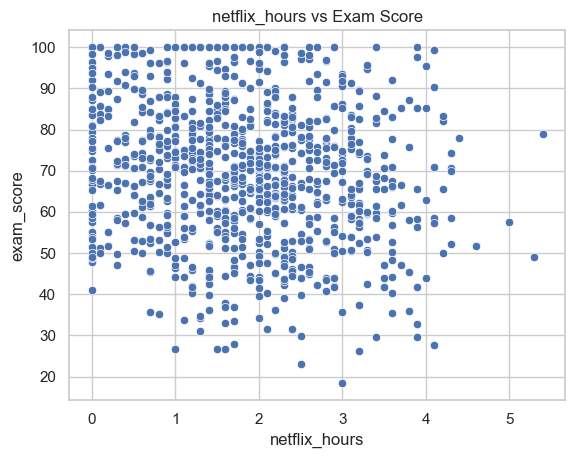

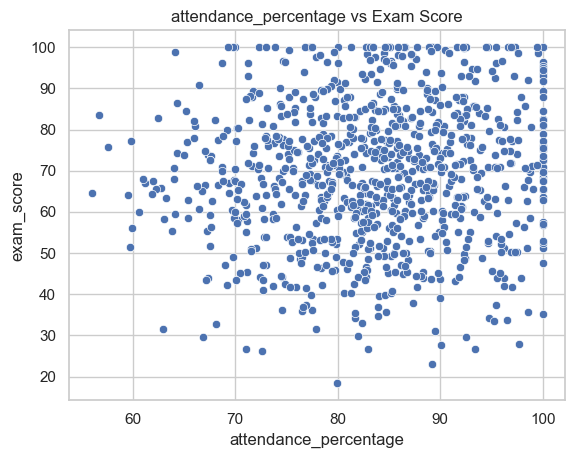

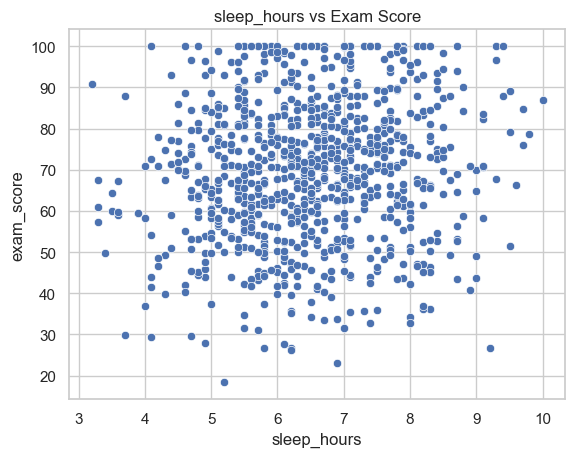

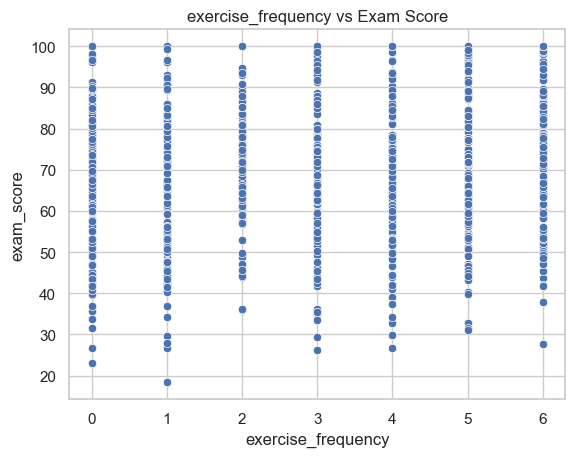

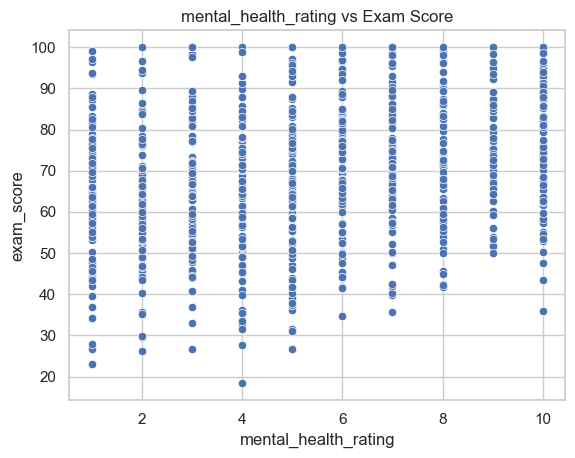

In [23]:
for feature in num_features:
    sns.scatterplot(data = df, x = feature, y = "exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

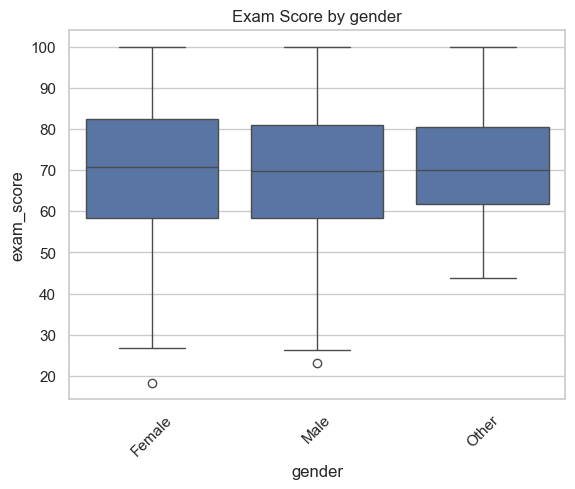

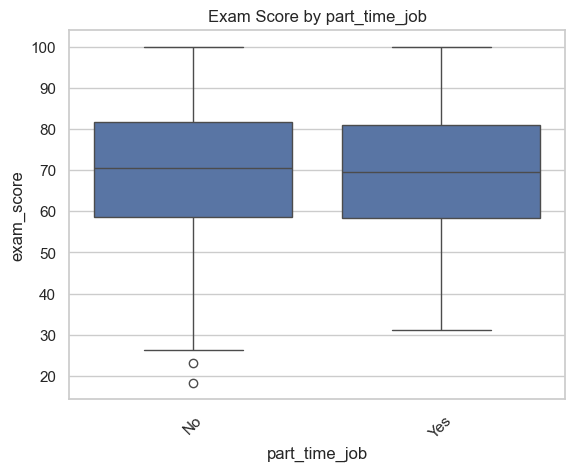

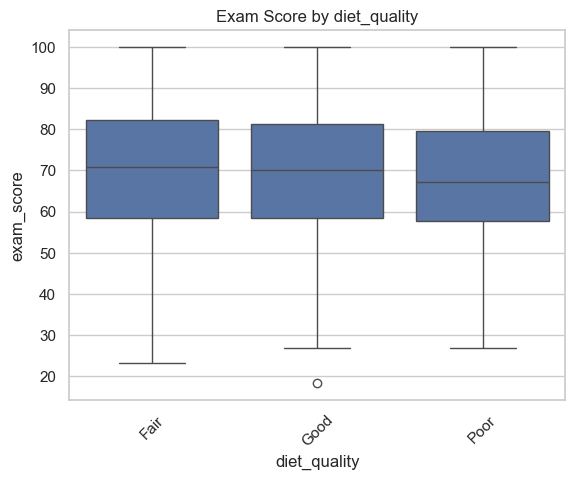

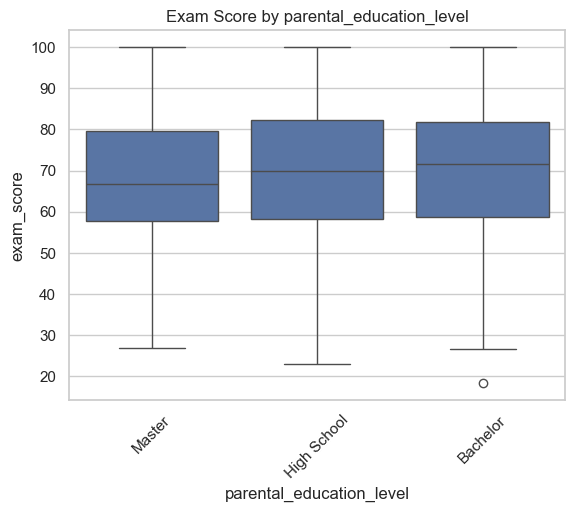

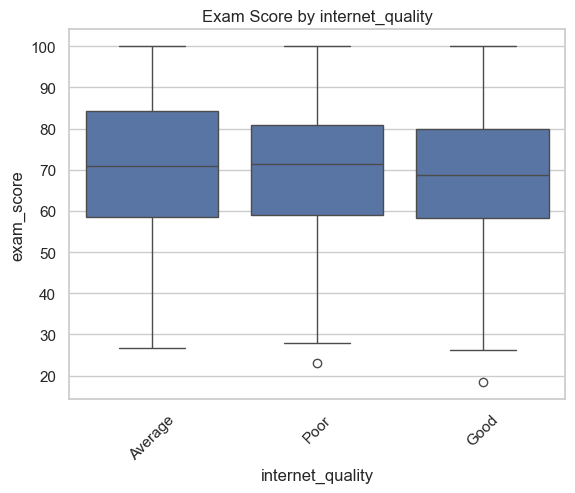

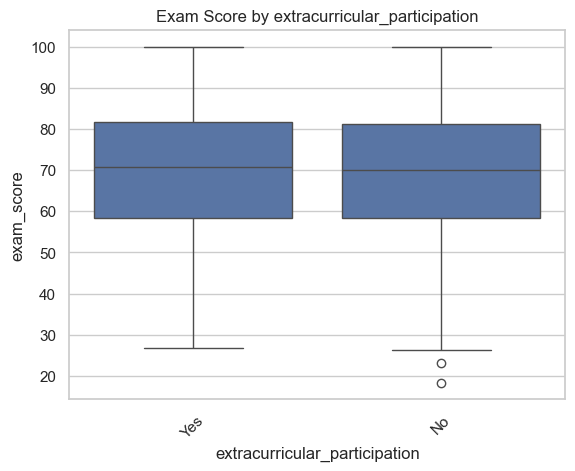

In [24]:
for col in categorical_cols:
    sns.boxplot(data = df, x = col, y = "exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation = 45)
    plt.show()

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [26]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [27]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [28]:
features = ["study_hours_per_day", "attendance_percentage", "mental_health_rating", "sleep_hours", "part_time_job"]

In [29]:
target = "exam_score"

In [30]:
df_model = df[features + [target]].copy()

In [31]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [32]:
le = LabelEncoder()

In [33]:
le.fit_transform(df_model["part_time_job"])

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In [34]:
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [35]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [36]:
X = df_model[features]

In [37]:
y = df_model[target]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [39]:
len(y_test)

182

In [40]:
len(y_train)

727

In [41]:
models = {
    "LinearRegression" : {
        "model" : LinearRegression(),
        "params" : {}
    },
    "DecisionTreeClassifier" : {
        "model" : DecisionTreeRegressor(),
        "params" : {"max_depth" : [3,5,10], "min_samples_split" : [2,5]}
    },
    "RandomForest" : {
        "model" : RandomForestRegressor(),
        "params" : {"n_estimators": [50,100], "max_depth" : [5,10]}
    }
}

In [42]:
best_models = []

In [43]:
for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(config["model"], config["params"], cv = 5, scoring = "neg_mean_squared_error")
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)


    best_models.append({
        "model" : name,
        "best_params" : grid.best_params_,
        "rmse" : rmse,
        "r2" : r2
    })


Training LinearRegression
Training DecisionTreeClassifier
Training RandomForest


In [44]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.308773003705466),
  'r2': 0.7924774376108608},
 {'model': 'DecisionTreeClassifier',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.823449497524784),
  'r2': 0.697550283132272},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': np.float64(7.833588121838506),
  'r2': 0.7616046169482474}]

In [45]:
resutls_df = pd.DataFrame(best_models)

In [46]:
resutls_df.sort_values(by = "rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.308773,0.792477
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",7.833588,0.761605
1,DecisionTreeClassifier,"{'max_depth': 5, 'min_samples_split': 5}",8.823449,0.697550


In [47]:
import joblib

best_row = resutls_df.sort_values(by = "rmse").iloc[0]

In [48]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.308773
r2                     0.792477
Name: 0, dtype: object

In [49]:
best_model_name = best_row["model"]

In [50]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.308773
r2                     0.792477
Name: 0, dtype: object

In [51]:
best_model_name

'LinearRegression'

In [52]:
best_model_config = models[best_model_name]

In [53]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [54]:
final_model = best_model_config["model"]

In [55]:
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
joblib.dump(final_model, "best_models.pkl")

['best_models.pkl']

In [57]:
joblib.load("best_models.pkl").predict(X_test)

array([ 71.89251839,  65.38478204,  74.47177811,  70.99577013,
        62.15277743,  54.84649087,  87.78875123,  96.72667692,
        47.10026421,  79.37860514,  56.58691108,  65.13307337,
        42.12695617,  80.02826427,  75.11171869,  56.25121079,
        66.16326409,  61.2642645 ,  60.6209758 ,  50.56118245,
        78.89418139,  86.85962666,  61.89130361,  39.6867241 ,
        61.37643194,  77.09472949,  63.72550851,  76.84828965,
        44.84571488,  87.69201972,  48.2945095 ,  58.02616961,
        47.74082004,  70.71589384,  88.7920053 ,  49.82715484,
        63.63790671,  78.2264766 ,  80.61992577,  37.08526345,
        81.64018775,  53.20974487,  86.19114402,  96.41397838,
        88.45015169,  55.72437836,  59.38276315,  88.8343056 ,
        78.30936564,  68.15955942,  69.19275373,  83.69220041,
        53.68824906,  51.19094234,  68.01649762,  44.07751614,
        64.17680333,  64.87101299,  78.89156923,  42.51199279,
        62.717919  , 102.05443373,  84.3068876 ,  71.17